In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

# Upload file manually
uploaded = files.upload()

# Check uploaded files
print(os.listdir())

# Load dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Display first 5 rows
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
['.config', 'Titanic-Dataset.csv', 'sample_data']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0

In [9]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Survival Count
print("\nSurvival Count:")
print(df['Survived'].value_counts())

# Gender Count
print("\nGender Count:")
print(df['Sex'].value_counts())

# Passenger Class Count
print("\nPassenger Class Count:")
print(df['Pclass'].value_counts())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Gender Count:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class Count:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [13]:
# Fill Missing Values properly
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column only if it exists
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# Check Missing Values Again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Set Plot Style
sns.set_style("whitegrid")


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


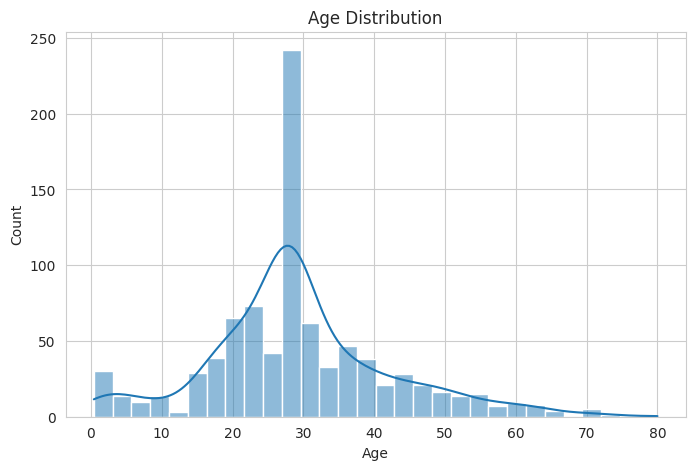

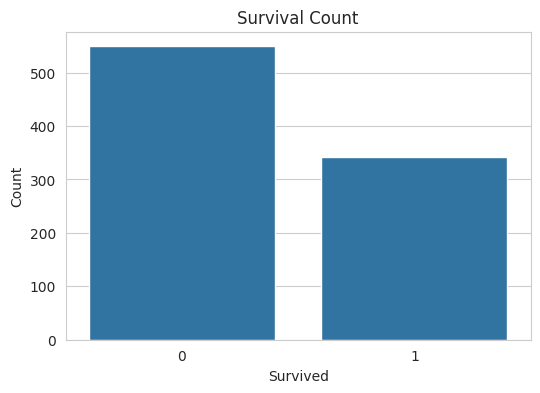

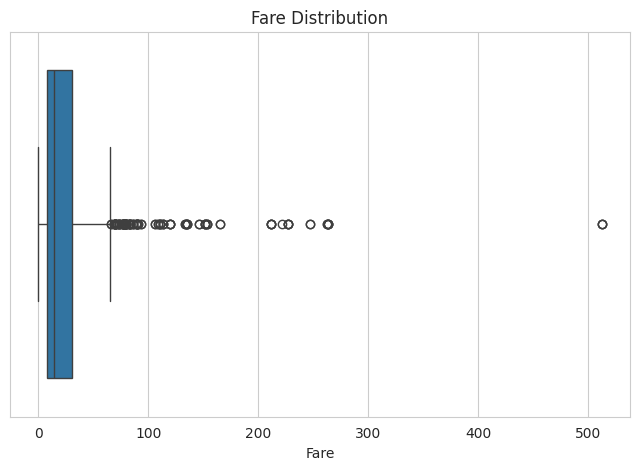

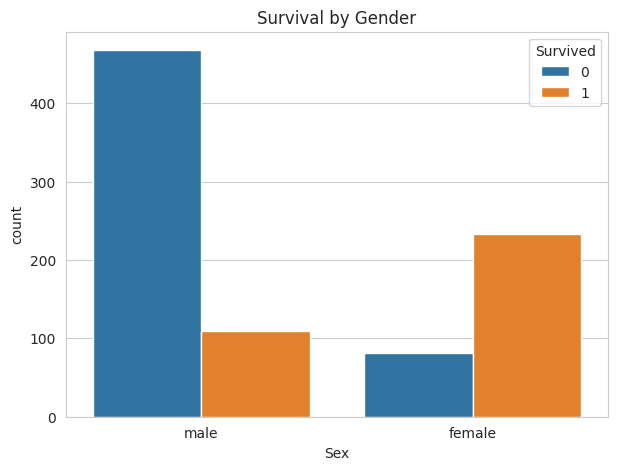

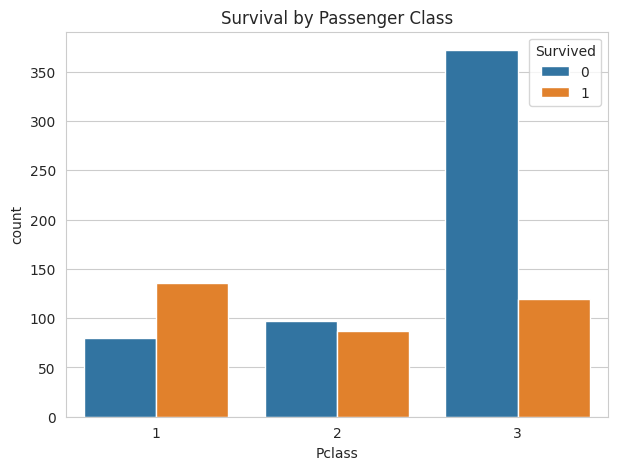

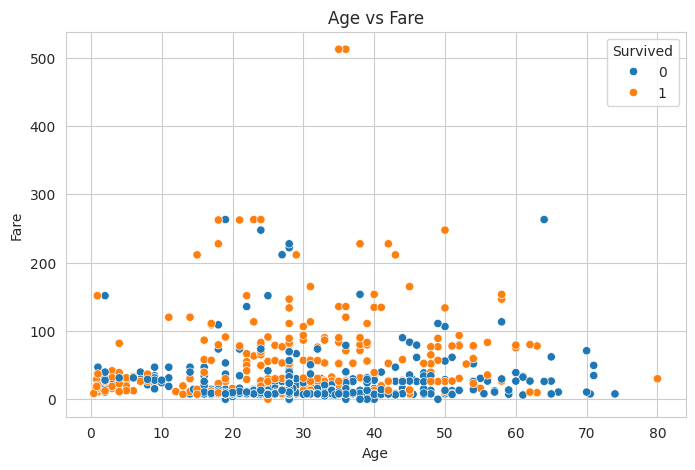

In [15]:
# Histogram for Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Survival Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Boxplot for Fare
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution')
plt.show()

# Survival by Gender
plt.figure(figsize=(7,5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(7,5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

# Scatter Plot: Age vs Fare
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare')
plt.show()

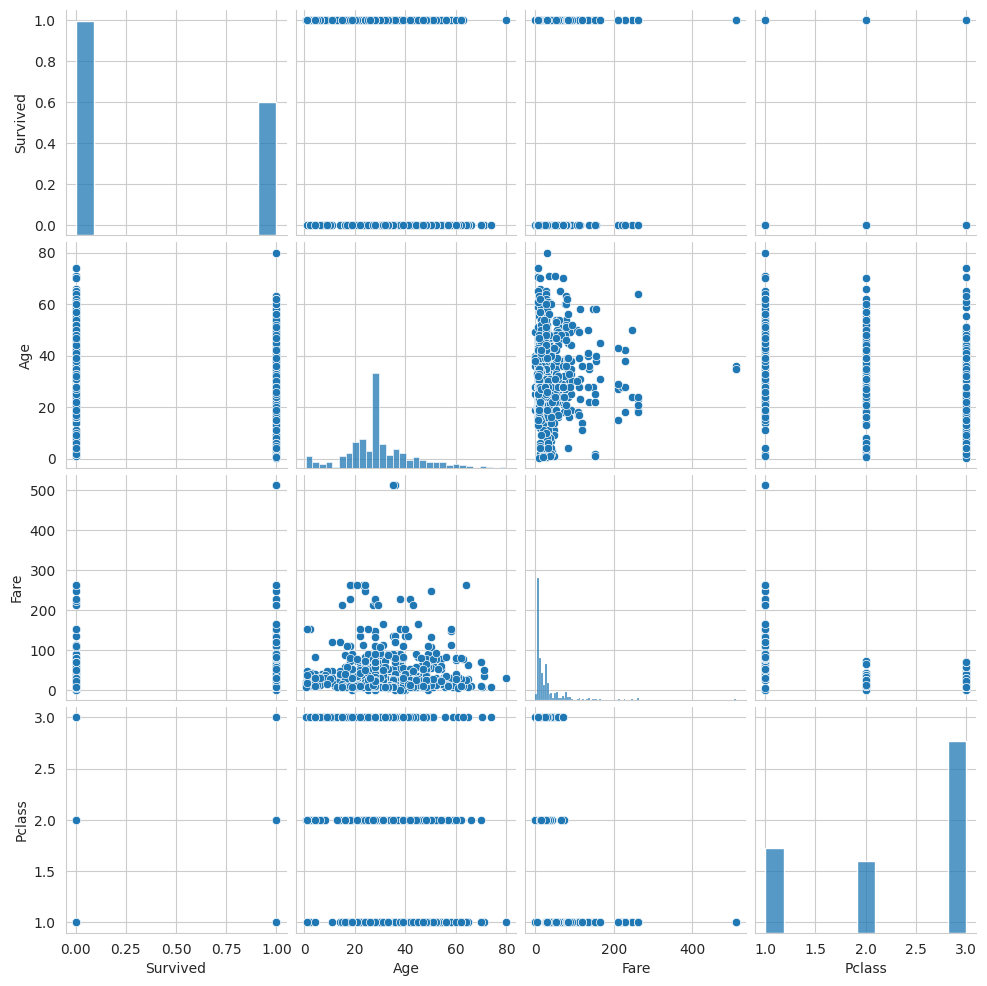

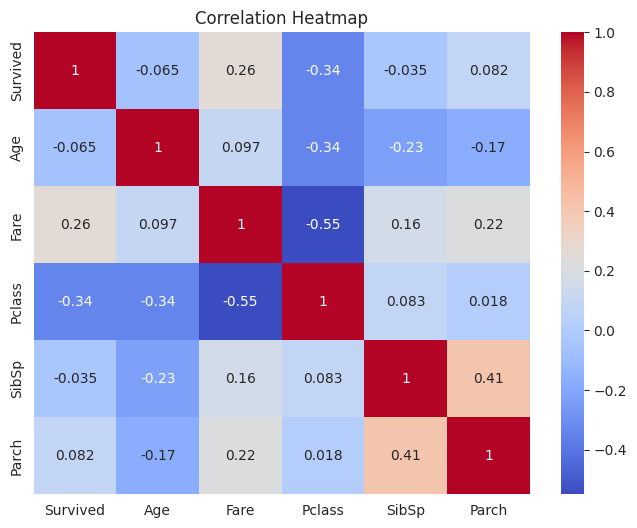


Summary of Findings:
1. Most passengers were between 20 and 40 years old.
2. More passengers died than survived.
3. Female passengers had a much higher survival rate than males.
4. First-class passengers had better survival chances.
5. Fare contains several outliers.
6. Passengers with higher fares had higher survival chances.
7. Passenger class and fare are strongly related.
8. Age does not have a very strong correlation with survival.


In [16]:
# Pairplot for Multiple Variables
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
correlation = df[['Survived', 'Age', 'Fare', 'Pclass', 'SibSp', 'Parch']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Final Summary
print("\nSummary of Findings:")
print("1. Most passengers were between 20 and 40 years old.")
print("2. More passengers died than survived.")
print("3. Female passengers had a much higher survival rate than males.")
print("4. First-class passengers had better survival chances.")
print("5. Fare contains several outliers.")
print("6. Passengers with higher fares had higher survival chances.")
print("7. Passenger class and fare are strongly related.")
print("8. Age does not have a very strong correlation with survival.")

In [19]:
# Save cleaned dataset
df.to_csv('cleaned_titanic_dataset.csv', index=False)

print("Cleaned dataset saved successfully.")

from google.colab import files
files.download('cleaned_titanic_dataset.csv')

Cleaned dataset saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>